In [45]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as la

In [117]:
# nominal CoSMO type
n_strains = 2
n_resources = 3

c = np.zeros((n_strains,n_resources))
c[0,0] = 2
c[1,0] = 2
c[0,1] = 2
c[1,2] = 2

l = np.zeros((n_strains,n_resources))
degree = 1
l[0,0] = 1*degree
l[1,0] = 1*degree

#nutrient "quality"
w = np.ones(n_resources)

#chemostat feeding
k = np.zeros(n_resources)
k[0] = 3

#chemostat dilution rate
r = np.ones(n_resources)*1
#r = np.array([1,0.2,0.2])

#death rate
m = np.ones(n_strains)*0.9

tau = 1

B = 1/tau*m


CF_array = np.zeros((n_strains,n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)
CF_array[0,2,0] = 1
CF_array[1,1,0] = 1

print(c)

print(CF_array)

ratios = np.array([0.49,0.51])

D = np.array([0.01,0.01]) #diffusion constant for cells

H = np.array([10,1,1]) #diffusion constants for resources



[[2. 2. 0.]
 [2. 0. 2.]]
[[[0. 0. 0.]
  [0. 0. 0.]
  [1. 0. 0.]]

 [[0. 0. 0.]
  [1. 0. 0.]
  [0. 0. 0.]]]


In [118]:
"""
# nominal CoSMO circle, separate glucoses
n_strains = 3
n_resources = 6

c = np.zeros((n_strains,n_resources))
c[0,0] = 2
c[1,1] = 2
c[2,2] = 2
c[0,3] = 2
c[1,4] = 2
c[2,5] = 2

l = np.array([1,1,1,0,0,0])

w = np.array([1,1,1,1,1,1])

k = np.array([1,1,1,0,0,0])

r = np.array([1,1,1,0.2,0.2,0.2])

m = np.array([0.9,0.9,0.9])

tau = 1

B = 1/tau*m


CF_array = np.zeros((n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)
CF_array[4,0] = 1
CF_array[5,1] = 1
CF_array[3,2] = 1

print(c)
print(CF_array)

ratios = np.array([0.3,0.5,0.2])

D = np.array([0.01,0.01,0.01]) #diffusion constant for cells

H = np.array([100,100,100,1,1,1]) #diffusion constants for resources
"""

'\n# nominal CoSMO circle, separate glucoses\nn_strains = 3\nn_resources = 6\n\nc = np.zeros((n_strains,n_resources))\nc[0,0] = 2\nc[1,1] = 2\nc[2,2] = 2\nc[0,3] = 2\nc[1,4] = 2\nc[2,5] = 2\n\nl = np.array([1,1,1,0,0,0])\n\nw = np.array([1,1,1,1,1,1])\n\nk = np.array([1,1,1,0,0,0])\n\nr = np.array([1,1,1,0.2,0.2,0.2])\n\nm = np.array([0.9,0.9,0.9])\n\ntau = 1\n\nB = 1/tau*m\n\n\nCF_array = np.zeros((n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)\nCF_array[4,0] = 1\nCF_array[5,1] = 1\nCF_array[3,2] = 1\n\nprint(c)\nprint(CF_array)\n\nratios = np.array([0.3,0.5,0.2])\n\nD = np.array([0.01,0.01,0.01]) #diffusion constant for cells\n\nH = np.array([100,100,100,1,1,1]) #diffusion constants for resources\n'

In [119]:
"""

# nominal linear chain
n_strains = 2
n_resources = 4

c = np.zeros((n_strains,n_resources))
c[0,0] = 2
c[1,1] = 0
c[0,2] = 0
c[1,3] = 2

l = np.array([0.5,0,0,0])

w = np.array([1,1,1,1])

k = np.array([1,1,0,0])

r = np.array([1,1,0.2,0.2])

m = np.array([0.6,0.4])

tau = 1

B = 1/tau*m


CF_array = np.zeros((n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)
CF_array[3,0] = 1
#CF_array[2,1] = 1

print(c)
print(CF_array)

"""

'\n\n# nominal linear chain\nn_strains = 2\nn_resources = 4\n\nc = np.zeros((n_strains,n_resources))\nc[0,0] = 2\nc[1,1] = 0\nc[0,2] = 0\nc[1,3] = 2\n\nl = np.array([0.5,0,0,0])\n\nw = np.array([1,1,1,1])\n\nk = np.array([1,1,0,0])\n\nr = np.array([1,1,0.2,0.2])\n\nm = np.array([0.6,0.4])\n\ntau = 1\n\nB = 1/tau*m\n\n\nCF_array = np.zeros((n_resources,n_resources)) # the MiCRM crossfeeding array (D_ab in their parlance)\nCF_array[3,0] = 1\n#CF_array[2,1] = 1\n\nprint(c)\nprint(CF_array)\n\n'

In [120]:
def get_steady_state(n_strains,n_resources,ratios,c,l,w,k,r,m,tau,H,CF_array,N_0,R_0,dt,t_final):
    
    steady_state = False
    
    attempts = 0
    
    while not steady_state:
        
        if attempts > 0:
            
            t_final = t_final*2
            print('No steady state found on attempt %s'%attempts, ' running for longer')
            
            
        epsilon = 1e-4
        t_min = 30
        
        
        nsteps = int(t_final/dt)

        time = np.zeros(nsteps+1)

        N = np.zeros((n_strains,nsteps+1))
        N[:,0] = N_0*ratios

        R = np.zeros((n_resources,nsteps+1)) + R_0
        #R[0,0] = R_0

        for tt in range(nsteps):


            #I am too lazy to figure out matricies, although I'm sure that's easy
            dN = np.zeros(n_strains)
            for ii in range(n_strains):
                dN[ii] = -1/tau*N[ii,tt]*m[ii]
                for aa in range(n_resources):
                    dN[ii] += 1/tau*N[ii,tt]*(1-l[ii,aa])*w[aa]*c[ii,aa]*R[aa,tt]

            dR = np.zeros(n_resources)
            for aa in range(n_resources):
                dR[aa] = k[aa] - r[aa]*R[aa,tt]

                for ii in range(n_strains):
                    dR[aa] += -N[ii,tt]*c[ii,aa]*R[aa,tt]

                    for bb in range(n_resources):
                        dR[aa] += N[ii,tt]*CF_array[ii,aa,bb]*l[ii,bb]*w[bb]/w[aa]*c[ii,bb]*R[bb,tt]


            N[:,tt+1] = N[:,tt] + dN*dt
            R[:,tt+1] = R[:,tt] + dR*dt
            time[tt+1] = time[tt]+dt


            if time[tt+1] > t_min and np.sum(dN) < epsilon and not steady_state:
                steady_state = True
                Nss = N[:,tt+1]
                Rss = R[:,tt+1]
                Tss = time[tt+1]
                #break
        
        attempts += 1
        
        if attempts > 5:
            break
    
    return N[:,:tt+1],R[:,:tt+1],time[:tt+1],Nss,Rss,Tss

In [121]:
#troubleshooting for the steady state function

N_0 = 1
R_0 = 0
dt = 0.001
t_final = 50

N,R,time,Nss,Rss,Tss = get_steady_state(n_strains,n_resources,ratios,c,l,w,k,r,m,tau,H,CF_array,N_0,R_0,dt,t_final)

print(Nss,Rss)

[0.74999232 0.74999232] [0.75000664 0.45000272 0.45000272]


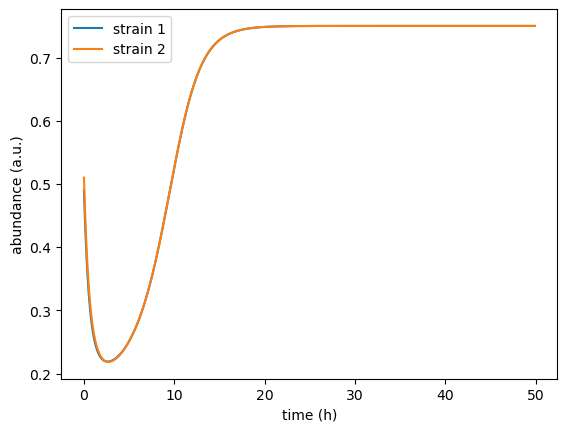

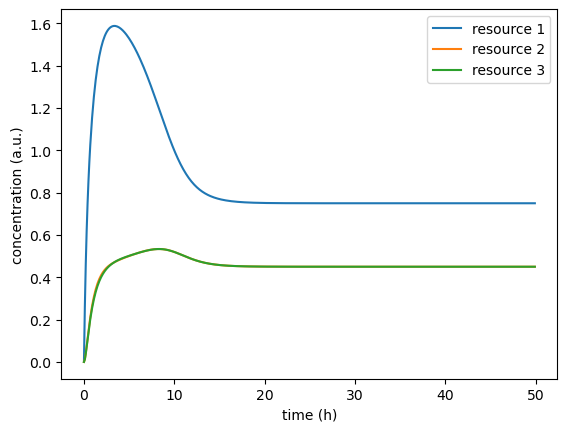

In [122]:
stride = 100
for nn in range(n_strains):
    plt.plot(time[::stride],N[nn,::stride],label='strain %s'%int(nn+1))
    #plt.axhline(y=Nss[nn])
plt.legend()
#plt.axvline(x=Tss)
plt.xlabel('time (h)')
plt.ylabel('abundance (a.u.)')
plt.show()

for rr in range(n_resources):
    plt.plot(time[::stride],R[rr,::stride],label='resource %s'%int(rr+1))
plt.legend()
plt.xlabel('time (h)')
plt.ylabel('concentration (a.u.)')
plt.show()


In [123]:
def get_A_F(n_strains, n_resources, tau,l,w,c,CF_array):
    
    # make A
    A = np.zeros((n_resources,n_strains))
    for aa in range(n_resources):
        for ii in range(n_strains):
            A[aa,ii] = tau*(1-l[ii,aa])*w[aa]*c[ii,aa]
            
    #make F
    F = np.zeros((n_strains,n_resources,n_resources))
    for ii in range(n_strains):
        for aa in range(n_resources):
            for bb in range(n_resources):
                F[ii,aa,bb] = CF_array[ii,aa,bb]*l[ii,bb]*w[bb]/w[aa]*c[ii,bb]
                
    return A,F

In [124]:
def calc_T(n_strains,n_resources,Nss,Rss,A,B,D,q):
    
    T = np.zeros((n_strains,n_strains))
    
    for ii in range(n_strains):
        #this matrix is diagonal, so we only need to loop through once
        T[ii,ii] = -D[ii]*q**2 - B[ii]
        
        for bb in range(n_resources):
             T[ii,ii] += Rss[bb]*A[bb,ii]
    
    return T

def calc_U(n_strains,n_resources,Nss,A):
    
    U = np.zeros((n_strains,n_resources))
    for ii in range(n_strains):
        for aa in range(n_resources):
            U[ii,aa] = A[aa,ii]*Nss[ii]
            
    return U

def calc_W(n_strains,n_resources,Nss,F,H,r,c,q):
    
    W = np.zeros((n_resources,n_resources))
    for aa in range(n_resources):
        for bb in range(n_resources):
            if aa==bb:
                #print('H = ',np.size(H))
                #print('r = ',np.size(r))
                W[aa,bb] = -(q**2*H[aa] + r[aa])
            else:
                W[aa,bb]
        
            for jj in range(n_strains):

                W[aa,bb] += Nss[jj]*F[jj,aa,bb]
                
                if aa==bb:
                    
                    W[aa,bb] += -Nss[jj]*c[jj,aa]
    
    return W

def calc_V(n_strains,n_resources,Rss,F,c):
    
    V = np.zeros((n_resources,n_strains))
    for aa in range(n_resources):
        for ii in range(n_strains):
            V[aa,ii] = -c[ii,aa]*Rss[aa]
            
            for bb in range(n_resources):
                V[aa,ii] += F[ii,aa,bb]*Rss[bb]
    return V

def build_big_matrix(n_strains,n_resources,Nss,Rss,U,V,A,B,D,F,H,r,c,q):
    
    M = np.zeros((int(n_strains+n_resources),int(n_strains+n_resources)))
    
    T = calc_T(n_strains,n_resources,Nss,Rss,A,B,D,q)
    W = calc_W(n_strains,n_resources,Nss,F,H,r,c,q)
    
    M[0:n_strains,0:n_strains] = T
    M[0:n_strains,n_strains:] = U
    M[n_strains:,0:n_strains] = V
    M[n_strains:,n_strains:] = W
    
    return M

"""
#lets actually calculate some stuff!
#first, the steady state for our parameter set
N_0 = 0.02
R_0 = 1
dt = 0.01
t_final = 1000
Nss,Rss,Tss = get_steady_state(n_strains,n_resources,c,l,w,k,r,m,tau,D,H,CF_array,N_0,R_0,dt,t_final)
"""



'\n#lets actually calculate some stuff!\n#first, the steady state for our parameter set\nN_0 = 0.02\nR_0 = 1\ndt = 0.01\nt_final = 1000\nNss,Rss,Tss = get_steady_state(n_strains,n_resources,c,l,w,k,r,m,tau,D,H,CF_array,N_0,R_0,dt,t_final)\n'

In [125]:
# as U and V do not depend on q, we will pre-compute them for every steady state

A,F = get_A_F(n_strains, n_resources, tau,l,w,c,CF_array)

U = calc_U(n_strains,n_resources,Nss,A)
V = calc_V(n_strains,n_resources,Rss,F,c)

#now its time to calculate some lambdas as a function of q
npts = 10000
qs = np.linspace(0,100,npts)

#qs = 1/lengths

lambdas = np.zeros((int(n_strains+n_resources),npts))
max_vecs = []

for nn in range(npts):
    
    q = qs[nn]
    
    M = build_big_matrix(n_strains,n_resources,Nss,Rss,U,V,A,B,D,F,H,r,c,q)
    
    vals,vecs = la.eig(M)
    
    lambdas[:,nn] = vals

    """
    if nn == 1:
        print(vals)
        print(np.amax(vals))
        print(vecs[:,vals==np.amax(vals)])
    """
    
    max_vecs.append(vecs[:,vals==np.amax(vals)])



/tmpdir/job/2050203.undefined/ipykernel_163011/1828233799.py:25: ComplexWarning: Casting complex values to real discards the imaginary part
  lambdas[:,nn] = vals


unstable modes!
maximum eigenvalue = 0.11788769207498744
q at max =  0.6800680068006801
maximum eigenvector =  [[ 0.70032411]
 [ 0.70032411]
 [-0.10640093]
 [ 0.06233433]
 [ 0.06233433]]


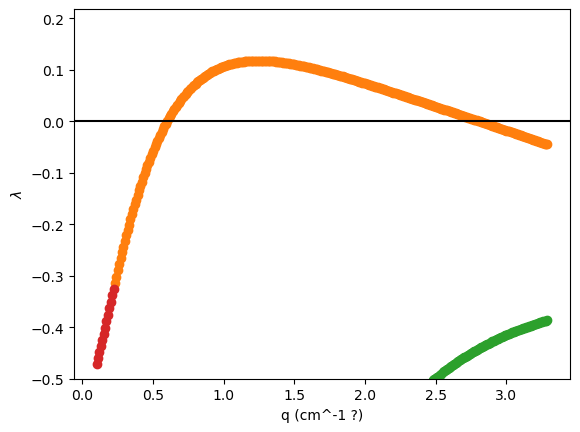

In [126]:
if (lambdas>0).any():
    print('unstable modes!')
    whr = np.where(lambdas>0)
    #print('unstable between %s and'%(1/qs[whr[1][-1]]),'%s'%(1/qs[whr[1][0]]))
    print('maximum eigenvalue = %s'%(np.amax(lambdas)))
    
    indx = np.where(lambdas == np.amax(lambdas))
    max_x = int(indx[1][0])
    print('q at max = ', qs[max_x])
    print('maximum eigenvector = ',max_vecs[max_x])
    
    
    av = np.mean(qs[whr[1][:]])
    sprd = np.amax(whr[1]) - np.amin(whr[1])
    
    
    add = 100
    rng = int(sprd+add)
    
    overshoot = np.amin(whr[1][0])-add/2
    
    if overshoot<0:
        strt = 0
        stp = int(np.amax(whr[1][:]) + add/2 - overshoot)
    
    else:
        
        strt = int(overshoot)
        stp = int(np.amax(whr[1][:]) + add/2)
    
    mx = np.amax(lambdas)+0.1
    mn = -0.5
    
    #strt = 0
    #stp = -1
    
    #plot the result!
    fig, ax = plt.subplots()
    #ax.set_xscale('log')
    #ax.set_xlim(0,10)
    for ii in range(int(n_strains+n_resources)):
        
        indx = int(strt+ii)
        
        ax.scatter(qs[strt:stp],lambdas[ii,strt:stp])
    plt.xlabel('q (cm^-1 ?)')
    plt.ylabel(r'$\lambda$')
    plt.ylim(mn,mx)
    plt.axhline(y=0,c='k')
    #plt.xlim(strt,stp)
    plt.show()

else:
    
    #plot the result!
    fig, ax = plt.subplots()
    #ax.set_xscale('log')
    #ax.set_xlim(0,10)
    for ii in range(int(n_strains+n_resources)):
        ax.scatter(qs,lambdas[ii,:])
    plt.xlabel('q (cm^-1)')
    plt.ylabel(r'$\lambda$')
    #plt.ylim(-1,1)
    #plt.xlim(-0.01,0.5)
    plt.show()
   

In [141]:
#PDE time!
# Grid parameters
L = 10.0                 # Domain size (square domain)
dx = dy = 0.1
nx, ny = int(L/dx), int(L/dx)         # Number of grid points
x = np.linspace(0, L, nx)
y = np.linspace(0, L, ny)
X, Y = np.meshgrid(x, y)

# Time parameters
t_final = 100          # Final time
dt = 0.0001               # Time step
nt = int(t_final / dt)  # Number of time steps

# Initialize arrays
N = np.zeros((n_strains, nx, ny, nt+1))
R = np.zeros((n_resources, nx, ny, nt+1))
running_av = np.zeros((n_strains+n_resources,nt+1))

mag = 0.1

for xx in range(nx):
    for yy in range(ny):
        for ss in range(n_strains):
            N[ss,xx,yy,0] = Nss[ss] + mag*np.random.normal()
            
        for rr in range(n_resources):
            R[rr,xx,yy,0] += Rss[rr] + mag*np.random.normal()

for ss in range(n_strains):
    running_av[ss,0] = np.mean(N[ss,:,:,0])
for rr in range(n_resources):
    running_av[rr+n_strains,0] = np.mean(R[rr,:,:,0])

In [142]:
# Helper function for Laplacian using finite differences with periodic boundary conditions
def laplacian(Z):
    Zup = np.roll(Z, -1, axis=0)
    Zdown = np.roll(Z, 1, axis=0)
    Zleft = np.roll(Z, -1, axis=1)
    Zright = np.roll(Z, 1, axis=1)
    
    return (Zup + Zdown + Zleft + Zright - 4*Z) / (dx**2)

In [143]:
# Time stepping
S = n_strains
M = n_resources

for t in range(nt):
    if t % int(nt/10) == 0:
        print(f"Step {t}/{nt}")
        np.save('2D_PDE_N_t_%s.npy'%int(t/dt),N[:,:,:,-1])
        np.save('2D_PDE_R_t_%s.npy'%int(t/dt),R[:,:,:,-1])
        np.save('2D_PDE_running_t_%s.npy'%int(t/dt),running_av)
    
    # Calculate derivatives for species N
    for i in range(S):
        dNdt = np.zeros((nx, ny))
        
        # Diffusion term
        dNdt += D[i] * laplacian(N[i, :, :, t])
        
        # Growth and mortality terms
        for alpha in range(M):
            dNdt += N[i, :, :, t] * (1 - l[i,alpha]) * w[alpha] * c[i, alpha] * R[alpha, :, :, t]
        
        dNdt -= N[i, :, :, t] * m[i]
        
        # Update
        N[i, :, :, t+1] = N[i, :, :, t] + dt * dNdt
        N[i, :, :, t+1] = np.maximum(N[i, :, :, t+1], 0.0)  # Ensure non-negative density
    
    # Calculate derivatives for resources R
    for alpha in range(M):
        dRdt = np.zeros((nx, ny))
        
        # Diffusion term
        dRdt += H[alpha] * laplacian(R[alpha, :, :, t])
        
        # Production and decay terms
        dRdt += k[alpha]
        dRdt -= r[alpha] * R[alpha, :, :, t]
        
        # Consumption terms
        for i in range(S):
            dRdt -= N[i, :, :, t] * c[i, alpha] * R[alpha, :, :, t]
        
        # Conversion terms (resource beta -> resource alpha)
        for i in range(S):
            for beta in range(M):
                dRdt += N[i, :, :, t] * CF_array[i, alpha, beta] * l[i,beta] * (w[beta]/w[alpha]) * c[i, beta] * R[beta, :, :, t]
        
        # Update
        R[alpha, :, :, t+1] = R[alpha, :, :, t] + dt * dRdt
        R[alpha, :, :, t+1] = np.maximum(R[alpha, :, :, t+1], 0.0)  # Ensure non-negative concentration

    for ss in range(n_strains):
        running_av[ss,t+1] = np.mean(N[ss,:,:,t+1])
    for rr in range(n_resources):
        running_av[rr+n_strains,t+1] = np.mean(R[rr,:,:,t+1])

Step 0/500000
Step 50000/500000
Step 100000/500000
Step 150000/500000
Step 200000/500000
Step 250000/500000
Step 300000/500000
Step 350000/500000
Step 400000/500000
Step 450000/500000


In [144]:
# Create visualization of initial and final states
def plot_state(time_idx, title_suffix):
    fig = plt.figure(figsize=(20, 10))

    # Plot 2D heatmaps in the second row
    for i in range(S):
        ax = fig.add_subplot(2, M+S, M+S+i+1)
        im = ax.imshow(N[i, :, :, time_idx], cmap='viridis', origin='lower', 
                      extent=[0, L, 0, L], vmin=0.1, vmax = 0.8)#vmax=np.max(N[i, :, :, time_idx])*1.1)
        ax.set_title(f'Species {i+1} {title_suffix} (2D)')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        fig.colorbar(im, ax=ax)
    
    for alpha in range(M):
        ax = fig.add_subplot(2, M+S, M+S+S+alpha+1)
        im = ax.imshow(R[alpha, :, :, time_idx], cmap='plasma', origin='lower', 
                      extent=[0, L, 0, L], vmin=0.1, vmax = 0.9) #vmax=np.max(R[alpha, :, :, time_idx])*1.1)
        ax.set_title(f'Resource {alpha+1} {title_suffix} (2D)')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        fig.colorbar(im, ax=ax)
    
    plt.tight_layout()
    return fig


In [ ]:
# Plot initial state
initial_fig = plot_state(0, "(Initial)")
initial_fig.savefig('initial_state.png')

# Plot final state
final_fig = plot_state(-1, "(Final)")
final_fig.savefig('final_state.png')

# Create time series plots of average values
plt.figure(figsize=(12, 6))

# Species average densities over time
plt.subplot(1, 2, 1)
for i in range(S):
    avg_density = np.mean(N[i, :, :, :], axis=(0, 1))
    plt.plot(np.linspace(0, t_final, nt+1), avg_density, label=f'Species {i+1}')
plt.xlabel('Time')
plt.ylabel('Average Density')
plt.title('Species Density Evolution')
plt.legend()
plt.grid(True)

# Resource average concentrations over time
plt.subplot(1, 2, 2)
for alpha in range(M):
    avg_conc = np.mean(R[alpha, :, :, :], axis=(0, 1))
    plt.plot(np.linspace(0, t_final, nt+1), avg_conc, label=f'Resource {alpha+1}')
plt.xlabel('Time')
plt.ylabel('Average Concentration')
plt.title('Resource Concentration Evolution')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('2D_PDE_solution_190325.png')

# Display plots
plt.show()

print("Simulation completed!")